# Download các thư viện cần thiết


In [1]:
import os
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Đọc file train (1 phần)


## Định nghĩa hàm đọc toàn bộ dataset


In [2]:
def read_parquet_by_type(train_path: str):
    # Lấy tất cả các file parquet trong thư mục
    files = [os.path.join(train_path, f) for f in os.listdir(train_path) if f.endswith('.parquet')]
    
    # Phân loại các file theo loại tên
    user_chunk_files = [file for file in files if 'user_chunk' in file]
    purchase_history_chunk_files = [file for file in files if 'purchase_history_daily_chunk' in file]
    item_chunk_files = [file for file in files if 'item_chunk' in file]
    
    # Đọc các file riêng biệt thành DataFrame
    user_chunk_df = pl.concat([pl.read_parquet(file) for file in user_chunk_files]) if user_chunk_files else None
    purchase_history_chunk_df = pl.concat([pl.read_parquet(file) for file in purchase_history_chunk_files]) if purchase_history_chunk_files else None
    item_chunk_df = pl.concat([pl.read_parquet(file) for file in item_chunk_files]) if item_chunk_files else None
    
    # Trả về một dictionary chứa các DataFrame
    return {
        "user_chunk": user_chunk_df,
        "purchase_history_chunk": purchase_history_chunk_df,
        "item_chunk": item_chunk_df
    }

## Đọc toàn bộ dataset


In [3]:
train_path = './dataset'
dataframes = read_parquet_by_type(train_path)

## Kiểm tra DataFrame của từng loại data trong dataset


In [4]:
print("User Chunk DataFrame:")
dataframes["user_chunk"]

User Chunk DataFrame:


customer_id,gender,location,province,membership,timestamp,created_date,updated_date,sync_status_id,last_sync_date,sync_error_message,region,location_name,install_app,install_date,district,user_id,is_deleted
i32,str,i32,str,str,i64,datetime[μs],datetime[μs],i32,datetime[μs],str,str,str,str,i64,str,str,bool
14732,"""Nam""",155,"""Hồ Chí Minh""","""Standard""",1306357911,2011-05-25 21:11:51.677,2025-07-07 15:33:10.201316,2,2025-07-16 11:54:29.816986,null,"""Đông Nam Bộ""","""HCM - Grand View Phú Mỹ Hưng""","""In-Store""",1306281600,"""7""","""e1e48206652bf8c279ff0206c69a80…",false
15126,"""Nữ""",300,"""Hồ Chí Minh""","""Standard""",1306357911,2011-05-25 21:11:51.677,2025-07-07 15:33:10.201316,2,2025-07-16 11:54:29.816986,null,"""Đông Nam Bộ""","""HCM - 121A Nguyễn Duy Trinh""","""In-Store""",1306281600,"""Thủ Đức""","""77891759204bd27e69fb11a7b92889…",false
29718,"""Nữ""",157,"""Bến Tre""","""Standard""",1312126692,2011-07-31 15:38:12.750,2025-07-07 15:33:10.201316,2,2025-07-16 11:54:29.816986,null,"""Đồng bằng sông Cửu Long""","""BTR - 179 Nguyễn Đình Chiểu""","""In-Store""",1582070400,"""Bến Tre""","""b8041b584a0bb6655361727a0a6108…",false
30077,"""Nữ""",53,"""Hồ Chí Minh""","""Standard""",1314302782,2011-08-25 20:06:22.797,2025-07-07 15:33:10.201316,2,2025-07-16 11:54:29.816986,null,"""Đông Nam Bộ""","""HCM - 101 Trần Quang Khải""","""In-Store""",1314230400,"""1""","""c52ceaca44a83ec41a219cfaff0e05…",false
30085,"""Nữ""",660,"""Hồ Chí Minh""","""Standard""",1314310024,2011-08-25 22:07:04.267,2025-07-07 15:33:10.201316,2,2025-07-16 11:54:29.816986,null,"""Đông Nam Bộ""","""HCM - 85-87 Tây Thạnh""","""In-Store""",1314230400,"""Tân Phú""","""74ac5764f5d67d341aacf238d7762f…",false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
8800478,"""Nữ""",186,"""Đồng Nai""","""Standard""",1749987601,2025-06-15 11:40:01.437,2025-09-23 17:43:56.503,2,2025-07-16 12:17:47.648696,null,"""Đông Nam Bộ""","""DON - 07 Lê Lợi""","""In-Store""",1749945600,"""Long Khánh""","""0a7d1ac011c868e8121f75a86704a7…",false
8814340,"""Nữ""",385,"""Long An""","""Standard""",1750318260,2025-06-19 07:31:00.073,2025-06-19 07:31:00.337,2,2025-07-16 12:17:47.648696,null,"""Đồng bằng sông Cửu Long""","""LAN - 277-278 ĐT835""","""In-Store""",1750291200,"""Bến Lức""","""af28e0cce3fe4a97ad95d4dcd194e6…",false
8810998,"""Nam""",1092,"""Bạc Liêu""","""Standard""",1750234662,2025-06-18 08:17:42.230,2025-06-18 08:17:42.637,2,2025-07-16 12:17:47.648696,null,"""Đồng bằng sông Cửu Long""","""BLI - Phan Ngọc Hiển""","""In-Store""",1750204800,"""Đông Hải""","""7607bd452a7b880af0505c27fd0222…",false


# **Tiền xử lý dữ liệu**


In [10]:
user_chunk_df = dataframes['user_chunk']
user_chunk_df

customer_id,gender,location,province,membership,timestamp,created_date,updated_date,sync_status_id,last_sync_date,sync_error_message,region,location_name,install_app,install_date,district,user_id,is_deleted
i32,str,i32,str,str,i64,datetime[μs],datetime[μs],i32,datetime[μs],str,str,str,str,i64,str,str,bool
14732,"""Nam""",155,"""Hồ Chí Minh""","""Standard""",1306357911,2011-05-25 21:11:51.677,2025-07-07 15:33:10.201316,2,2025-07-16 11:54:29.816986,null,"""Đông Nam Bộ""","""HCM - Grand View Phú Mỹ Hưng""","""In-Store""",1306281600,"""7""","""e1e48206652bf8c279ff0206c69a80…",false
15126,"""Nữ""",300,"""Hồ Chí Minh""","""Standard""",1306357911,2011-05-25 21:11:51.677,2025-07-07 15:33:10.201316,2,2025-07-16 11:54:29.816986,null,"""Đông Nam Bộ""","""HCM - 121A Nguyễn Duy Trinh""","""In-Store""",1306281600,"""Thủ Đức""","""77891759204bd27e69fb11a7b92889…",false
29718,"""Nữ""",157,"""Bến Tre""","""Standard""",1312126692,2011-07-31 15:38:12.750,2025-07-07 15:33:10.201316,2,2025-07-16 11:54:29.816986,null,"""Đồng bằng sông Cửu Long""","""BTR - 179 Nguyễn Đình Chiểu""","""In-Store""",1582070400,"""Bến Tre""","""b8041b584a0bb6655361727a0a6108…",false
30077,"""Nữ""",53,"""Hồ Chí Minh""","""Standard""",1314302782,2011-08-25 20:06:22.797,2025-07-07 15:33:10.201316,2,2025-07-16 11:54:29.816986,null,"""Đông Nam Bộ""","""HCM - 101 Trần Quang Khải""","""In-Store""",1314230400,"""1""","""c52ceaca44a83ec41a219cfaff0e05…",false
30085,"""Nữ""",660,"""Hồ Chí Minh""","""Standard""",1314310024,2011-08-25 22:07:04.267,2025-07-07 15:33:10.201316,2,2025-07-16 11:54:29.816986,null,"""Đông Nam Bộ""","""HCM - 85-87 Tây Thạnh""","""In-Store""",1314230400,"""Tân Phú""","""74ac5764f5d67d341aacf238d7762f…",false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
8800478,"""Nữ""",186,"""Đồng Nai""","""Standard""",1749987601,2025-06-15 11:40:01.437,2025-09-23 17:43:56.503,2,2025-07-16 12:17:47.648696,null,"""Đông Nam Bộ""","""DON - 07 Lê Lợi""","""In-Store""",1749945600,"""Long Khánh""","""0a7d1ac011c868e8121f75a86704a7…",false
8814340,"""Nữ""",385,"""Long An""","""Standard""",1750318260,2025-06-19 07:31:00.073,2025-06-19 07:31:00.337,2,2025-07-16 12:17:47.648696,null,"""Đồng bằng sông Cửu Long""","""LAN - 277-278 ĐT835""","""In-Store""",1750291200,"""Bến Lức""","""af28e0cce3fe4a97ad95d4dcd194e6…",false
8810998,"""Nam""",1092,"""Bạc Liêu""","""Standard""",1750234662,2025-06-18 08:17:42.230,2025-06-18 08:17:42.637,2,2025-07-16 12:17:47.648696,null,"""Đồng bằng sông Cửu Long""","""BLI - Phan Ngọc Hiển""","""In-Store""",1750204800,"""Đông Hải""","""7607bd452a7b880af0505c27fd0222…",false


In [6]:
user_chunk_df.columns

['customer_id',
 'gender',
 'location',
 'province',
 'membership',
 'timestamp',
 'created_date',
 'updated_date',
 'sync_status_id',
 'last_sync_date',
 'sync_error_message',
 'region',
 'location_name',
 'install_app',
 'install_date',
 'district',
 'user_id',
 'is_deleted']

## Task 1: Loại bỏ các cột mà nhóm nghĩ là không cần thiết.

Sau khi bàn luận về tính thực tế cũng như sự chính xác của mô hình phục vụ cho bài toán *Khuyến nghị mua hàng*, nhóm em quyết định loại bỏ một số cột không cần thiết như:

| **Cột**               | **Lý do loại bỏ**                                                                                              |
|-----------------------|----------------------------------------------------------------------------------------------------------------|
| `timestamp`           | Không liên quan trực tiếp đến bài toán khuyến nghị mua hàng, trừ khi phân tích hành vi theo thời gian.        |
| `created_date`        | Không cần thiết nếu không dùng để phân tích hành vi người dùng khi gia nhập hệ thống.                         |
| `updated_date`        | Không cần thiết nếu không dùng để phân tích hành vi người dùng khi cập nhật thông tin.                         |
| `sync_status_id`      | Liên quan đến trạng thái đồng bộ hệ thống, không phục vụ trực tiếp cho việc khuyến nghị mua hàng.             |
| `last_sync_date`      | Cùng lý do như `sync_status_id`, không phục vụ trực tiếp cho bài toán khuyến nghị.                            |
| `sync_error_message`  | Thông tin lỗi hệ thống không có ảnh hưởng đến việc tạo ra các khuyến nghị mua hàng.                         |
| `install_date`        | Không cần thiết nếu không dùng để phân tích hành vi người dùng sau khi cài đặt ứng dụng (ví dụ như thời gian dùng thử). |
| `is_deleted`          | Dữ liệu trong cột này 100% là giá trị `false` => không thể cung cấp thông tin quan trọng nào để mô hình có thể học được. |
|   `user_id`           | Tần suất xuất hiện của từng id trong trường thông tin này chỉ xuất hiện đúng **1 lần** theo như thống kê đơn biến từ bước EDA, như vậy thì mỗi `user_id` sẽ tương ứng với mỗi `customer_id` => theo kinh nghiệm 2 trường này sẽ có độ tương quan là 1|


In [23]:
# Danh sách các cột đã bị loại bỏ
columns_to_drop = ['timestamp', 'created_date', 'updated_date', 'sync_status_id', 
                   'last_sync_date', 'sync_error_message', 'install_date', 'user_id', 'is_deleted']

# Chọn các cột không có trong columns_to_drop
preprocessed_df = user_chunk_df.select([col for col in user_chunk_df.columns if col not in columns_to_drop])
preprocessed_df

customer_id,gender,location,province,membership,region,location_name,install_app,district
i32,str,i32,str,str,str,str,str,str
14732,"""Nam""",155,"""Hồ Chí Minh""","""Standard""","""Đông Nam Bộ""","""HCM - Grand View Phú Mỹ Hưng""","""In-Store""","""7"""
15126,"""Nữ""",300,"""Hồ Chí Minh""","""Standard""","""Đông Nam Bộ""","""HCM - 121A Nguyễn Duy Trinh""","""In-Store""","""Thủ Đức"""
29718,"""Nữ""",157,"""Bến Tre""","""Standard""","""Đồng bằng sông Cửu Long""","""BTR - 179 Nguyễn Đình Chiểu""","""In-Store""","""Bến Tre"""
30077,"""Nữ""",53,"""Hồ Chí Minh""","""Standard""","""Đông Nam Bộ""","""HCM - 101 Trần Quang Khải""","""In-Store""","""1"""
30085,"""Nữ""",660,"""Hồ Chí Minh""","""Standard""","""Đông Nam Bộ""","""HCM - 85-87 Tây Thạnh""","""In-Store""","""Tân Phú"""
…,…,…,…,…,…,…,…,…
8800478,"""Nữ""",186,"""Đồng Nai""","""Standard""","""Đông Nam Bộ""","""DON - 07 Lê Lợi""","""In-Store""","""Long Khánh"""
8814340,"""Nữ""",385,"""Long An""","""Standard""","""Đồng bằng sông Cửu Long""","""LAN - 277-278 ĐT835""","""In-Store""","""Bến Lức"""
8810998,"""Nam""",1092,"""Bạc Liêu""","""Standard""","""Đồng bằng sông Cửu Long""","""BLI - Phan Ngọc Hiển""","""In-Store""","""Đông Hải"""


## Task 2: Xử lý NULL, Xử lý Outlier

In [24]:
# Tạo danh sách các giá trị "không xác định"
undefined_values = ['Không xác định', 'na', 'null', 'NaN', None]

# Hàm kiểm tra null và "Không xác định"
def check_null_and_undefined(df):
    null_columns = []
    undefined_columns = []
    total_rows = df.height

    # Duyệt qua tất cả các cột
    for column in df.columns:
        # Chuyển cột dữ liệu về kiểu String (nếu chưa phải kiểu String)
        df_column = df[column].cast(pl.Utf8)
        
        # Lọc các giá trị null và "Không xác định"
        null_count = df_column.is_null().sum()  # Số giá trị null
        undefined_count = df_column.is_in(undefined_values).sum()  # Số giá trị "Không xác định"
        
        # Nếu có giá trị null
        if null_count > 0:
            null_columns.append((column, null_count, (null_count / total_rows) * 100))
        
        # Nếu có giá trị "Không xác định"
        if undefined_count > 0:
            undefined_columns.append((column, undefined_count, (undefined_count / total_rows) * 100))
    
    return null_columns, undefined_columns

# Gọi hàm và hiển thị kết quả
null_columns, undefined_columns = check_null_and_undefined(user_chunk_df)

# In kết quả rõ ràng
print("Các cột chứa giá trị Null:")
for column, total_null, percentage in null_columns:
    print(f"Cột: {column} | Số giá trị Null: {total_null} | Tỷ lệ: {percentage}%")

print("\nCác cột chứa giá trị 'Không xác định':")
for column, total_undefined, percentage in undefined_columns:
    print(f"Cột: {column} | Số giá trị 'Không xác định': {total_undefined} | Tỷ lệ: {percentage}%")


Các cột chứa giá trị Null:
Cột: sync_status_id | Số giá trị Null: 338285 | Tỷ lệ: 7.395882433705206%
Cột: last_sync_date | Số giá trị Null: 338285 | Tỷ lệ: 7.395882433705206%
Cột: sync_error_message | Số giá trị Null: 4573964 | Tỷ lệ: 100.0%

Các cột chứa giá trị 'Không xác định':
Cột: install_app | Số giá trị 'Không xác định': 5 | Tỷ lệ: 0.00010931437151669754%


Kết quả ở trên là những cột tồn tại giá trị Null và giá trị "Không xác định", đa số các cột chứa Null là các cột vừa bỏ ở **Task 1**

In [26]:
# Danh sách các cột đã bị loại bỏ
columns_to_drop = ['timestamp', 'created_date', 'updated_date', 'sync_status_id', 
                   'last_sync_date', 'sync_error_message', 'install_date', 'user_id' ,'is_deleted']

# Lọc các dòng có giá trị "Không xác định" trong trường install_app
filtered_df = user_chunk_df.filter(user_chunk_df['install_app'] == 'Không xác định')

# Chọn các cột không có trong columns_to_drop
filtered_df = filtered_df.select([col for col in filtered_df.columns if col not in columns_to_drop])

# Chọn 5 dòng đầu tiên
top_5_rows = filtered_df

# In ra kết quả
top_5_rows


customer_id,gender,location,province,membership,region,location_name,install_app,district
i32,str,i32,str,str,str,str,str,str
1777945,"""Nữ""",281,"""Bình Thuận""","""Standard""","""Duyên hải Nam Trung Bộ""","""BTH - 45 Trần Hưng Đạo""","""Không xác định""","""Phan Thiết"""
3132818,"""Nữ""",893,"""Hồ Chí Minh""","""Standard""","""Đông Nam Bộ""","""HCM - 705 Nguyễn Thị Định""","""Không xác định""","""Thủ Đức"""
6278323,"""Nam""",549,"""Lâm Đồng""","""Standard""","""Tây Nguyên""","""LDO - 19-21 Thống Nhất""","""Không xác định""","""Đức Trọng"""
6692881,"""Nữ""",491,"""Hồ Chí Minh""","""Gold""","""Đông Nam Bộ""","""HCM - Kho Online Big Order""","""Không xác định""","""7"""
6950757,"""Nam""",281,"""Bình Thuận""","""Standard""","""Duyên hải Nam Trung Bộ""","""BTH - 45 Trần Hưng Đạo""","""Không xác định""","""Phan Thiết"""


Thông tin về các `install_apps` chỉ chứa 5 giá trị "Không xác định" (chiếm tỷ lệ rất nhỏ so với tổng số dữ liệu - $0.0001 \% $). Nhóm đề xuất bỏ các dòng dữ liệu này

Xét theo ý tố khác phân tích đa biến, trường thông tin `install_apps` có độ tương đồng khá nhỏ ($ < 0.37 \%$) với các lớp, nên việc dùng phương pháp nội suy cho việc xử lý Null không thực sự khả thi

In [27]:
before = preprocessed_df.height
print("before: ", before)
# Drop các dòng có install_app == "Không xác định"
preprocessed_df = preprocessed_df.filter(
    pl.col("install_app") != "Không xác định"
    # Nếu muốn đồng thời bỏ cả null:
    # & pl.col("install_app").is_not_null()
)

after = preprocessed_df.height
print(f"Đã loại bỏ {before - after} dòng. Còn lại {after} dòng.")

before:  4573964
Đã loại bỏ 5 dòng. Còn lại 4573959 dòng.


In [28]:
# Kiểm tra lại
# Danh sách các cột đã bị loại bỏ
columns_to_drop = ['timestamp', 'created_date', 'updated_date', 'sync_status_id', 
                   'last_sync_date', 'sync_error_message', 'install_date', 'is_deleted']

# Lọc các dòng có giá trị "Không xác định" trong trường install_app
filtered_df = preprocessed_df.filter(preprocessed_df['install_app'] == 'Không xác định')

# Chọn các cột không có trong columns_to_drop
filtered_df = filtered_df.select([col for col in filtered_df.columns if col not in columns_to_drop])

# Chọn 5 dòng đầu tiên
top_5_rows = filtered_df

# In ra kết quả
top_5_rows


customer_id,gender,location,province,membership,region,location_name,install_app,district
i32,str,i32,str,str,str,str,str,str


## Task 3: Phân tích tương đồng và xác định xem các thuộc tính tương tự nhau. Từ đó loại bỏ đặc trưng thừa.

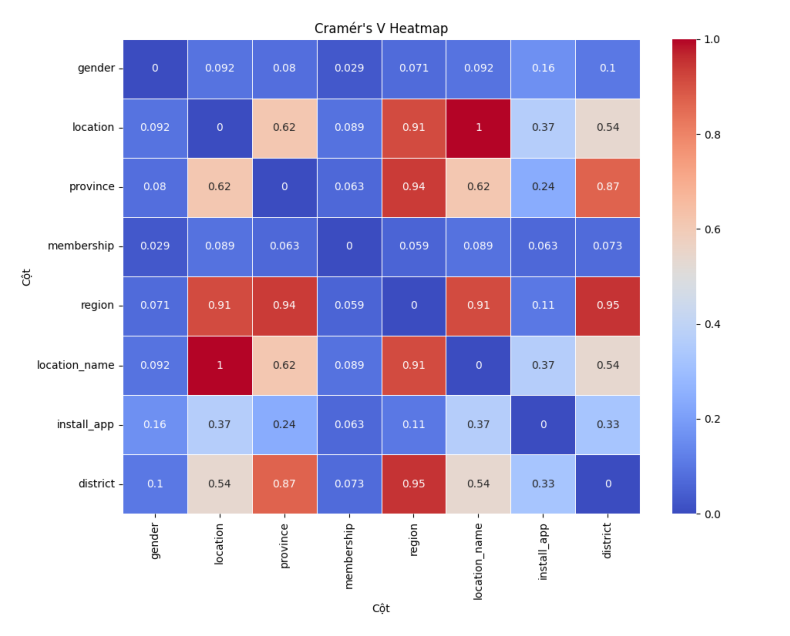

In [31]:
from PIL import Image
import matplotlib.pyplot as plt
import os, shutil, pathlib

path = "./images/user-chunk/DaBien/cramers_v_heatmap.png"

if not os.path.exists(path):
    raise FileNotFoundError(f"Không tìm thấy file: {path}")

plt.figure(figsize=(10, 8))
img = Image.open(path)
plt.imshow(img)
plt.axis('off')
plt.show()

Dựa vào biểu đồ heatmap biểu thị độ tương đồng giữa các biến categorical đã được phân tích từ bước EDA từ trước, một số thông tin nhóm nhận thấy được là:

- `location` có độ tương đồng cramér's V với `location_name` là 1.

- `location_name`: Đây là sự kết hợp của `province` và **địa chỉ cụ thể**, do đó thông tin trong location_name có thể chứa đầy đủ thông tin của cột `province. Tuy nhiên, dạng dữ liệu của nó lại có tính đặc thù (ví dụ: "HCM - Grand View Phú Mỹ Hưng"), điều này có thể dẫn đến khó khăn khi phân tích và mô hình hóa, vì các giá trị như vậy có thể cần phải được xử lý đặc biệt (ví dụ: tách thông tin để phân loại).

- `location` và `province`: Hai cột này có độ tương đồng khá cao với nhau và với `location_name`. Tuy nhiên, chúng có thể mang lại thông tin quan trọng về các vùng miền hoặc nhóm người dùng cụ thể.

- Ngoài ra, nếu đứng vào vị trí khách hàng khi thực hiện bài toán *khuyến nghị mua hàng*, việc khách hàng quan tâm đến vị trị cụ thể của người mua là rất ít.

=> Quyết định cuối cùng là nhóm quyết định bỏ cột `location_name`

Nhìn vào biểu đồ heatmap, `province` có độ tương quan khá lớn đối với `region` và `district` lần lượt là $0.94$ và $0.87$. Ngoài ra `region` và `district` có độ tương quan với nhau là $0.95$. Dựa trên thông tin về mối tương quan và phân tích bài toán khuyến nghị mua hàng, một vài lý do mạnh mẽ để loại bỏ hai cột `region` và `district`:

1. Tương quan cao giữa các cột:

    -  `province` vs `region`: 0.94, `province` vs `district`: 0.87, và `region` vs `district`: 0.95 cho thấy tất cả các cột này rất liên kết với nhau. Điều này có nghĩa là thông tin trong `region` và `district` có thể được dự đoán một cách gần như chính xác từ province.

2. Khách hàng ít quan tâm đến `region` và `district`:

    - Trong bài toán khuyến nghị mua hàng, sự phân biệt giữa `region` (vùng rộng lớn) và `district` (vùng cụ thể) có thể không mang lại giá trị bổ sung nhiều. Khách hàng không thường xuyên quan tâm đến sự khác biệt nhỏ giữa các khu vực nhỏ (district) hoặc các khu vực rộng (region). Trong khi đó, `province` vẫn có ý nghĩa đủ lớn để phân nhóm khách hàng mà không cần đến sự phân chia chi tiết hơn.

3. Tránh trùng lặp thông tin:

    - Việc giữ cả ba cột `province`, `region`, và `district` có thể tạo ra sự trùng lặp thông tin, vì chúng đều thể hiện các mức độ phân vùng địa lý khác nhau mà không mang lại giá trị thực sự khác biệt. province có thể đủ để mô tả thông tin về địa lý, còn region và district sẽ không cung cấp thông tin bổ sung quan trọng cho mô hình khuyến nghị.

=> Quyết định cuối cùng là nhóm quyết định bỏ cột `region` và `district`

## Task 4: Chuẩn hóa dữ liệu (nếu có), biến đổi dữ liệu

Theo kết quả trực quan hoá của phân tích đơn biến về trường thông tin `install_app`, dữ liệu trong trường thông tin này khá thiên lệch (phân bố không đều)

## Task 5: Nhóm hãy suy nghĩ xem, với bài toán dự đoán mua hàng, ta có thể tạo mới những đặc trưng nào. Sau đó tiến hành rút trích thêm các đặc trưng. Task này rất quan trọng vì ảnh hưởng hiệu quả của hệ thống.